# f6_m03b_errores_fpfn.ipynb

## Qué hace
Analiza el perfil de los errores del modelo: falsos positivos (FP) y falsos negativos (FN).
Un FP es un alumno que NO abandona pero el modelo predice que sí — alarma falsa.
Un FN es un alumno que SÍ abandona pero el modelo no lo detecta — el error más grave.
Busca patrones sistemáticos en los errores: ¿tienen algo en común los alumnos mal clasificados?
Modelo usado: CatBoost__balanced con umbral estándar 0.5.

## Requisitos
- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/X_test.parquet`
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`
- `data/03_features/df_exp_target_eda.parquet`

## Genera
- `results/fase6/errores_fpfn.parquet` — observaciones FP y FN con sus features
- `results/fase6/errores_distribucion.png` — distribución de probabilidades por tipo de error
- `results/fase6/errores_perfil_features.png` — comparativa de features medias FP vs FN vs correctos
- `results/fase6/errores_matriz_confusion.png` — matriz de confusión con contexto
- `docs/html/fase6/m03b_errores_fpfn.html`

## Flujo
Cargar datos → calcular predicciones → clasificar en TP/TN/FP/FN →
perfil de errores → gráficos → HTML

## Siguiente
`f6_m04a_stress.ipynb` — stress testing y robustez del modelo

In [1]:
# 1. CONFIGURACIÓN DE RUTAS
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA     = ROOT / 'data' / '05_modelado'
DIR_FEATURES = ROOT / 'data' / '03_features'
DIR_MODELS   = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS  = ROOT / 'results' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)

print(f'ROOT:        {ROOT}')
print(f'DIR_RESULTS: {DIR_RESULTS}')

ROOT:        C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# 2. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.metrics import confusion_matrix, classification_report
from src.html.render import render_pagina_desde_fichero

plt.rcParams['figure.dpi'] = 120

print('Imports OK.')

Imports OK.


In [3]:
# 3. CARGAR DATOS Y MODELO
# Calculamos predicciones con umbral estándar 0.5.
# X_test (sin prep) para el join con titulacion/rama.

X_test       = pd.read_parquet(DIR_DATA / 'X_test.parquet')
X_test_prep  = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
y_test       = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()
pipeline_cat = joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl')

y_true = y_test.values.ravel()
y_prob = pipeline_cat.predict_proba(X_test_prep)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'X_test_prep: {X_test_prep.shape}')
print(f'Abandono real:    {y_true.mean():.2%} ({y_true.sum()} alumnos)')
print(f'Abandono predicho:{y_pred.mean():.2%} ({y_pred.sum()} alumnos)')
print()
print(classification_report(y_true, y_pred, target_names=['No abandona', 'Abandona']))

X_test_prep: (6725, 19)
Abandono real:    29.25% (1967 alumnos)
Abandono predicho:31.87% (2143 alumnos)

              precision    recall  f1-score   support

 No abandona       0.92      0.88      0.90      4758
    Abandona       0.74      0.81      0.77      1967

    accuracy                           0.86      6725
   macro avg       0.83      0.85      0.84      6725
weighted avg       0.87      0.86      0.86      6725



In [4]:
# 4. CLASIFICAR OBSERVACIONES EN TP / TN / FP / FN
# TP: abandona y modelo detecta (acierto positivo)
# TN: no abandona y modelo descarta (acierto negativo)
# FP: no abandona pero modelo alerta — alarma falsa
# FN: abandona pero modelo no detecta — el error más costoso socialmente

tipo = np.where(
    (y_true == 1) & (y_pred == 1), 'TP',
    np.where(
        (y_true == 0) & (y_pred == 0), 'TN',
        np.where(
            (y_true == 0) & (y_pred == 1), 'FP', 'FN'
        )
    )
)

# Join con titulacion y rama
df_ref  = pd.read_parquet(DIR_FEATURES / 'df_exp_target_eda.parquet')
df_meta = df_ref[['titulacion', 'rama']].iloc[X_test.index].copy()
df_meta.index = X_test.index

# DataFrame completo con tipo de clasificación
df_errores = X_test_prep.copy()
df_errores['tipo']      = tipo
df_errores['y_true']    = y_true
df_errores['y_pred']    = y_pred
df_errores['y_prob']    = y_prob
df_errores['titulacion'] = df_meta['titulacion'].values
df_errores['rama']       = df_meta['rama'].values

conteo = df_errores['tipo'].value_counts()
total  = len(df_errores)
for t in ['TP', 'TN', 'FP', 'FN']:
    n = conteo.get(t, 0)
    print(f'{t}: {n:5d} ({n/total:.1%})')

# Guardar para análisis posteriores
df_errores.to_parquet(DIR_RESULTS / 'errores_fpfn.parquet')
print('\nGuardado: errores_fpfn.parquet')

TP:  1592 (23.7%)
TN:  4207 (62.6%)
FP:   551 (8.2%)
FN:   375 (5.6%)

Guardado: errores_fpfn.parquet


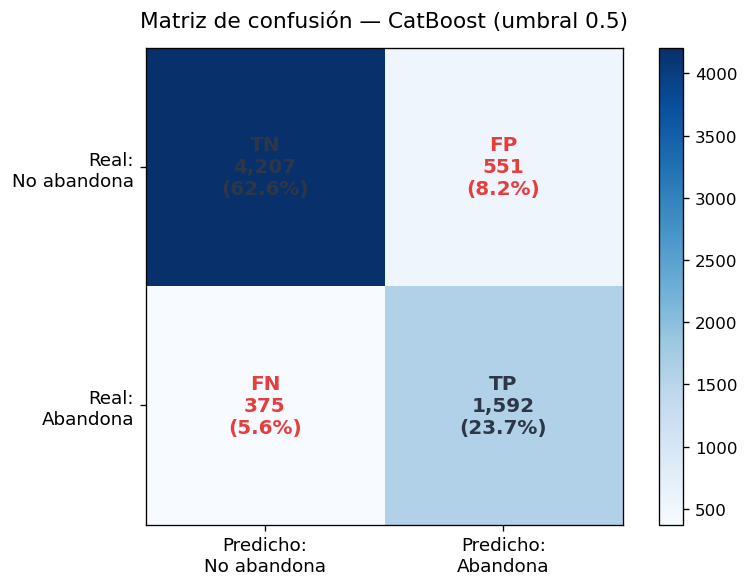

Matriz de confusión guardada.


In [5]:
# 5. GRÁFICO 1 — MATRIZ DE CONFUSIÓN
# Visualización clara de los 4 cuadrantes con conteos y porcentajes.

cm = confusion_matrix(y_true, y_pred)
etiquetas = ['No abandona', 'Abandona']

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicho:\nNo abandona', 'Predicho:\nAbandona'], fontsize=11)
ax.set_yticklabels(['Real:\nNo abandona', 'Real:\nAbandona'], fontsize=11)

tipos_cuadrante = [['TN', 'FP'], ['FN', 'TP']]
colores_texto   = [['#2d3748', '#e53e3e'], ['#e53e3e', '#2d3748']]

for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total
        ax.text(j, i, f'{tipos_cuadrante[i][j]}\n{cm[i,j]:,}\n({pct:.1%})',
                ha='center', va='center', fontsize=12, fontweight='bold',
                color=colores_texto[i][j])

ax.set_title('Matriz de confusión — CatBoost (umbral 0.5)', fontsize=13, pad=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
ruta_cm = DIR_RESULTS / 'errores_matriz_confusion.png'
plt.savefig(ruta_cm, dpi=120, bbox_inches='tight')
plt.show()
print('Matriz de confusión guardada.')

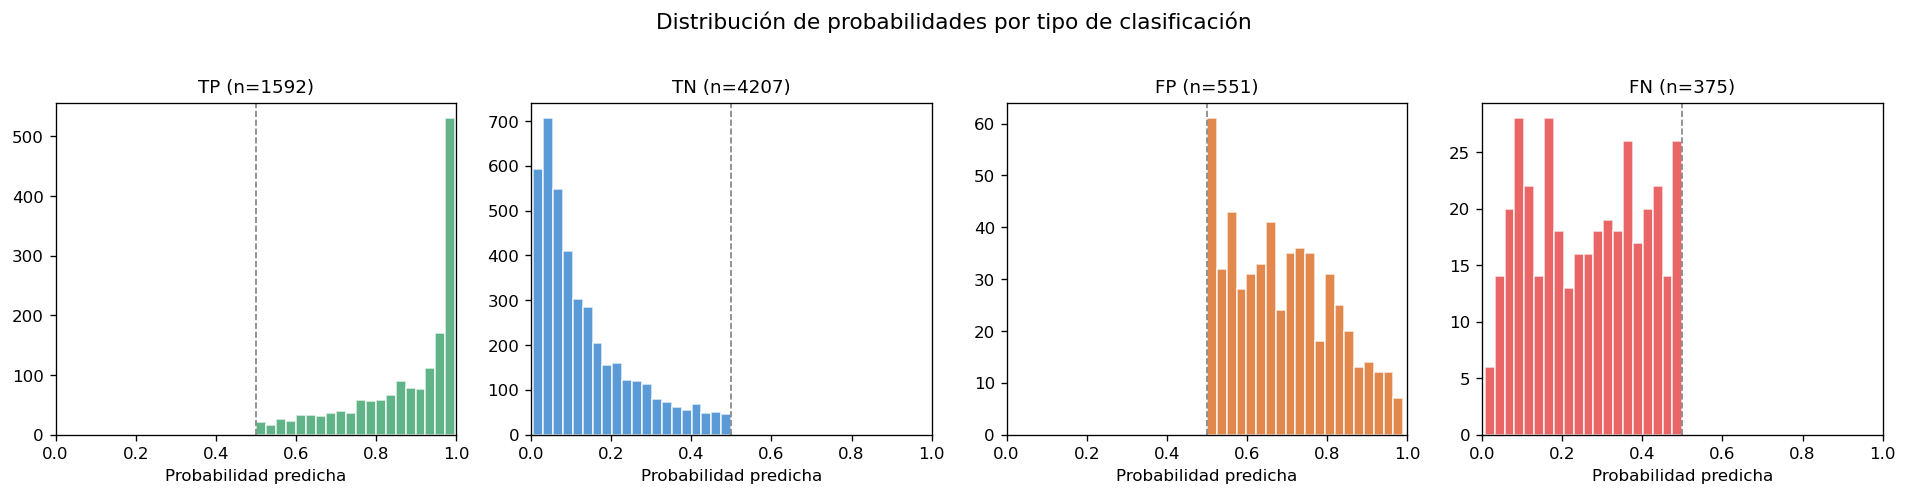

Distribución guardada.


In [6]:
# 6. GRÁFICO 2 — DISTRIBUCIÓN DE PROBABILIDADES POR TIPO
# Muestra cómo se distribuyen las probabilidades predichas
# para cada tipo de clasificación.
# FN con prob baja = errores difíciles (el modelo no tenía señal).
# FN con prob media = errores evitables ajustando el umbral.

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colores_tipo = {'TP': '#38a169', 'TN': '#3182ce', 'FP': '#dd6b20', 'FN': '#e53e3e'}

for ax, tipo_plot in zip(axes, ['TP', 'TN', 'FP', 'FN']):
    datos = df_errores[df_errores['tipo'] == tipo_plot]['y_prob']
    ax.hist(datos, bins=20, color=colores_tipo[tipo_plot], alpha=0.8, edgecolor='white')
    ax.set_title(f'{tipo_plot} (n={len(datos)})', fontsize=11)
    ax.set_xlabel('Probabilidad predicha')
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1)

plt.suptitle('Distribución de probabilidades por tipo de clasificación', fontsize=13, y=1.02)
plt.tight_layout()
ruta_dist = DIR_RESULTS / 'errores_distribucion.png'
plt.savefig(ruta_dist, dpi=120, bbox_inches='tight')
plt.show()
print('Distribución guardada.')

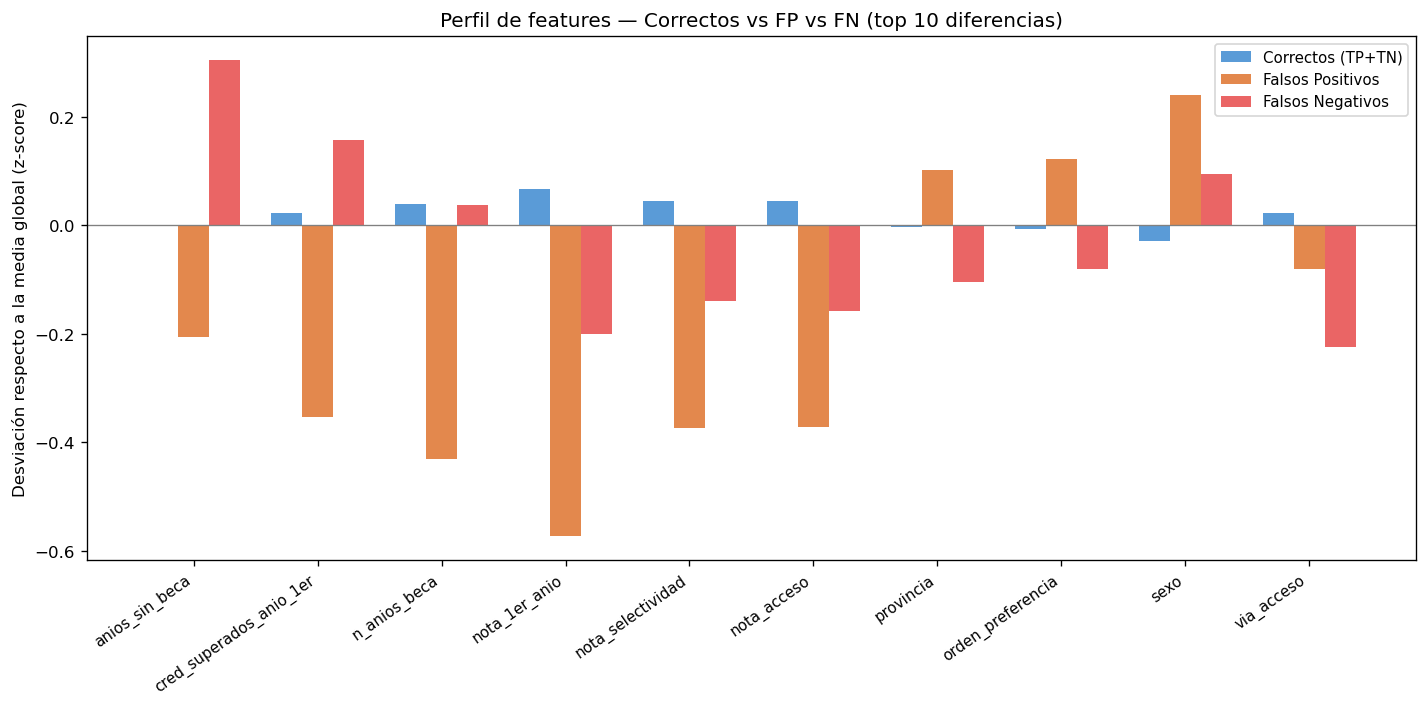

Perfil de features guardado.


In [7]:
# 7. GRÁFICO 3 — PERFIL DE FEATURES: FP vs FN vs CORRECTOS
features_numericas = X_test_prep.select_dtypes(include=[np.number]).columns.tolist()

# Usar índices posicionales para filtrar X_test_prep por tipo
mask_tp_tn = np.isin(tipo, ['TP', 'TN'])
mask_fp    = tipo == 'FP'
mask_fn    = tipo == 'FN'

grupos_comp = {
    'Correctos (TP+TN)': X_test_prep[mask_tp_tn],
    'Falsos Positivos':  X_test_prep[mask_fp],
    'Falsos Negativos':  X_test_prep[mask_fn],
}

medias_global = X_test_prep[features_numericas].mean()
stds_global   = X_test_prep[features_numericas].std().replace(0, 1)

df_perfil = pd.DataFrame({
    nombre: (grupo[features_numericas].mean() - medias_global) / stds_global
    for nombre, grupo in grupos_comp.items()
})

df_perfil['diff_fp_fn'] = (df_perfil['Falsos Positivos'] - df_perfil['Falsos Negativos']).abs()
top_feats = df_perfil.nlargest(10, 'diff_fp_fn').index.tolist()
df_plot   = df_perfil.loc[top_feats, ['Correctos (TP+TN)', 'Falsos Positivos', 'Falsos Negativos']]

fig, ax = plt.subplots(figsize=(12, 6))
x     = np.arange(len(top_feats))
ancho = 0.25
colores_grupos = ['#3182ce', '#dd6b20', '#e53e3e']

for i, (col, color) in enumerate(zip(df_plot.columns, colores_grupos)):
    ax.bar(x + i * ancho, df_plot[col], ancho, label=col, color=color, alpha=0.8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(top_feats, rotation=35, ha='right', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Desviación respecto a la media global (z-score)')
ax.set_title('Perfil de features — Correctos vs FP vs FN (top 10 diferencias)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
ruta_perfil = DIR_RESULTS / 'errores_perfil_features.png'
plt.savefig(ruta_perfil, dpi=120, bbox_inches='tight')
plt.show()
print('Perfil de features guardado.')

In [8]:
# 8. ANÁLISIS TEXTUAL — PATRONES EN ERRORES
# Refilter para asegurar que solo operamos sobre columnas realmente numéricas en df_errores
features_numericas = [c for c in features_numericas 
                      if c in df_errores.columns 
                      and pd.api.types.is_numeric_dtype(df_errores[c])]



fn = df_errores[df_errores['tipo'] == 'FN']
fp = df_errores[df_errores['tipo'] == 'FP']

print('=== PERFIL FALSOS NEGATIVOS (abandonan pero no detectados) ===')
print(f'Total FN: {len(fn)} ({len(fn)/total:.1%} del test)')
print(f'Prob media predicha: {fn["y_prob"].mean():.3f}')
print(f'Rama más frecuente: {fn["rama"].value_counts().index[0]}')
print(fn[features_numericas].mean().round(3).to_string())

print('\n=== PERFIL FALSOS POSITIVOS (no abandonan pero modelo alerta) ===')
print(f'Total FP: {len(fp)} ({len(fp)/total:.1%} del test)')
print(f'Prob media predicha: {fp["y_prob"].mean():.3f}')
print(f'Rama más frecuente: {fp["rama"].value_counts().index[0]}')
print(fp[features_numericas].mean().round(3).to_string())

print('\n=== COMPARATIVA FN vs FP (diferencias más grandes) ===')
diff = (fn[features_numericas].mean() - fp[features_numericas].mean()).abs().nlargest(5)
print(diff.round(3).to_string())

=== PERFIL FALSOS NEGATIVOS (abandonan pero no detectados) ===
Total FN: 375 (5.6% del test)
Prob media predicha: 0.264
Rama más frecuente: SO
cred_superados_anio_1er    0.130
nota_1er_anio             -0.205
nota_acceso               -0.153
sexo                       0.095
edad_entrada               0.030
pais_nombre                0.075
provincia                 -0.091
via_acceso                -0.187
orden_preferencia         -0.067
universidad_origen        -0.146
tuvo_beca                  0.039
n_anios_beca               0.041
situacion_laboral         -0.158
nota_selectividad         -0.148
max_pagos                  0.213
indicador_interrupcion     0.267
anios_gap                  0.202
anios_sin_beca             0.257

=== PERFIL FALSOS POSITIVOS (no abandonan pero modelo alerta) ===
Total FP: 551 (8.2% del test)
Prob media predicha: 0.690
Rama más frecuente: SO
cred_superados_anio_1er   -0.373
nota_1er_anio             -0.577
nota_acceso               -0.364
sexo             

In [9]:
# 9. GENERAR HTML
# render_pagina_desde_fichero — estándar del proyecto.

import base64

def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748; font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" style="max-width:100%; border-radius:6px; box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096; font-size:12px; margin-top:6px">{caption}</p>'
        '</div>'
    )

# Estadísticas para el resumen HTML
n_tp = conteo.get('TP', 0)
n_tn = conteo.get('TN', 0)
n_fp = conteo.get('FP', 0)
n_fn = conteo.get('FN', 0)

contenido = (
    '<h2 style="color:#2d3748">Análisis de Errores — Falsos Positivos y Falsos Negativos</h2>'
    '<p style="color:#4a5568; font-size:14px; max-width:800px">'
    'Caracterización de los errores del modelo CatBoost con umbral de decisión 0.5. '
    'Un <strong>falso negativo</strong> es un alumno que abandona pero el modelo no detecta — '
    'el error con mayor coste social porque el alumno no recibe intervención preventiva. '
    'Un <strong>falso positivo</strong> es un alumno que no abandona pero el modelo alerta — '
    'alarma falsa que consume recursos de orientación innecesariamente.'
    '</p>'
    '<div style="display:flex; gap:16px; margin:20px 0; flex-wrap:wrap">'
    f'<div style="padding:16px 24px; background:#f0fff4; border-radius:8px; text-align:center">'
    f'<div style="font-size:28px; font-weight:700; color:#38a169">{n_tp:,}</div>'
    f'<div style="font-size:12px; color:#718096">Verdaderos positivos<br>({n_tp/total:.1%})</div></div>'
    f'<div style="padding:16px 24px; background:#ebf8ff; border-radius:8px; text-align:center">'
    f'<div style="font-size:28px; font-weight:700; color:#3182ce">{n_tn:,}</div>'
    f'<div style="font-size:12px; color:#718096">Verdaderos negativos<br>({n_tn/total:.1%})</div></div>'
    f'<div style="padding:16px 24px; background:#fffbeb; border-radius:8px; text-align:center">'
    f'<div style="font-size:28px; font-weight:700; color:#dd6b20">{n_fp:,}</div>'
    f'<div style="font-size:12px; color:#718096">Falsos positivos<br>({n_fp/total:.1%})</div></div>'
    f'<div style="padding:16px 24px; background:#fff5f5; border-radius:8px; text-align:center">'
    f'<div style="font-size:28px; font-weight:700; color:#e53e3e">{n_fn:,}</div>'
    f'<div style="font-size:12px; color:#718096">Falsos negativos<br>({n_fn/total:.1%})</div></div>'
    '</div>'
    + bloque_imagen(img_b64(ruta_cm),
        'Matriz de confusión',
        'Distribución de los 4 tipos de clasificación. '
        'FN (rojo, abajo-izquierda) son los alumnos que abandonan sin ser detectados.')
    + bloque_imagen(img_b64(ruta_dist),
        'Distribución de probabilidades por tipo de clasificación',
        'Los FN con probabilidad baja son errores difíciles — el modelo no tenía señal suficiente. '
        'Los FN con probabilidad media (~0.4-0.5) son errores evitables bajando el umbral de decisión.')
    + bloque_imagen(img_b64(ruta_perfil),
        'Perfil de features — Correctos vs Falsos Positivos vs Falsos Negativos',
        'Desviación respecto a la media global (z-score). '
        'Permite identificar qué características distinguen a los alumnos mal clasificados '
        'de los correctamente clasificados.')
    + '<div style="margin-top:24px; padding:16px; background:#fff5f5; '
    + 'border-left:4px solid #e53e3e; border-radius:6px; font-size:13px; color:#742a2a">'
    + '<strong>Coste asimétrico de los errores:</strong> En detección de abandono universitario, '
    + 'un falso negativo tiene mayor coste social que un falso positivo. '
    + 'Si la institución prioriza no dejar pasar ningún caso de abandono, '
    + 'se recomienda bajar el umbral de decisión por debajo de 0.5, '
    + 'asumiendo un incremento controlado de falsos positivos.'
    + '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m03b_errores_fpfn.ipynb', contenido)
ruta_html = ROOT / 'docs' / 'html' / 'fase6' / 'm03b_errores_fpfn.html'
ruta_html.parent.mkdir(parents=True, exist_ok=True)
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'HTML generado: {ruta_html}')

HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m03b_errores_fpfn.html
